# From Pixels to Patches: Vision Transformers for Medical Image Understanding

**AI for Medicine Bootcamp — Workshop (3 Hours)**

In this workshop we apply the same intellectual spine from earlier sessions — **tokenization, embeddings, attention, pretraining, transfer learning** — to medical images. Instead of words or DNA bases, we work with image patches. Instead of masked language modeling, we use supervised classification. And we extend from single-modality (image-only) to multi-modal (image + text) understanding.

**What you will build:**
1. Explore a real radiology image-caption dataset (ROCOv2)
2. Tokenize images into patches — the visual equivalent of words
3. Build a Vision Transformer (ViT) from scratch and train it
4. Fine-tune a pretrained ViT with LoRA for medical image classification
5. Connect vision and language with contrastive learning (CLIP / BiomedCLIP)
6. Interpret what the model "sees" through attention visualization

---

**Table of Contents**

| Section | Topic | Time |
|---------|-------|------|
| 0 | Setup and Environment | — |
| 1 | The Big Picture — Why Transformers for Vision? | 0:00–0:15 |
| 2 | Data Tour — Radiology Images Meet Text | 0:15–0:35 |
| 3 | Image Tokenization — Seeing in Patches | 0:35–1:05 |
| 4 | Building a ViT from Scratch | 1:05–1:50 |
| 5 | Pre-trained ViT and Transfer Learning | 1:50–2:15 |
| 6 | Multimodal — From ViT to Vision-Language Models | 2:15–2:45 |
| 7 | Interpretation — What Does ViT See? | 2:45–2:55 |
| 8 | Wrap-Up | 2:55–3:00 |

> **Colab GPU:** Go to *Runtime → Change runtime type → T4 GPU* before running.

In [1]:
# ── Section 0: Setup and Environment ──────────────────────────────────────────
import sys, subprocess

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

# Pin Pillow first to avoid version conflicts between torchvision and open_clip
pip_install(["Pillow>=10.0,<11.0"])
pip_install([
    "-U", "transformers", "datasets", "peft", "accelerate",
    "timm", "open_clip_torch", "scikit-learn",
    "torchvision", "huggingface_hub",
])

import torch, torch.nn as nn, torch.nn.functional as F
import transformers, datasets, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torchvision.transforms as T
from PIL import Image
from IPython.display import display, HTML
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
)
from sklearn.manifold import TSNE
from collections import Counter
import warnings, re, math
warnings.filterwarnings("ignore")

print(f"torch: {torch.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"numpy: {np.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("GPU: Apple Silicon (MPS)")
else:
    device = torch.device("cpu")
    print("No GPU — running on CPU (training will be slower)")

USE_PRECOMPUTED = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})
sns.set_style("whitegrid")

torch: 2.10.0+cu128
transformers: 5.3.0
numpy: 2.0.2
GPU: Tesla T4


In [2]:
def plot_training_curves(train_losses, val_metrics, metric_name="Accuracy"):
    """Plot training loss and validation metric side-by-side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, linewidth=2, color="steelblue")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Training Loss")
    ax2.plot(val_metrics, linewidth=2, color="coral")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel(metric_name); ax2.set_title(f"Validation {metric_name}")
    plt.tight_layout(); plt.show()


def show_image_grid(images, titles=None, ncols=4, figsize=(16, 12)):
    """Display a grid of PIL images with optional titles."""
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(images[i])
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=9, wrap=True)
        ax.axis("off")
    plt.tight_layout(); plt.show()


def display_comparison_table(rows, columns, title=""):
    """Render an HTML table for side-by-side comparison."""
    html = f'<h3 style="color:black;">{title}</h3>' if title else ""
    html += '<table style="width:100%; border-collapse:collapse; font-size:13px; color:black;">'
    html += "<tr>" + "".join(
        f'<th style="border:1px solid #ccc; padding:8px; background:#f0f0f0; color:black;">{c}</th>'
        for c in columns
    ) + "</tr>"
    for row in rows:
        html += "<tr>" + "".join(
            f'<td style="border:1px solid #ccc; padding:8px; vertical-align:top; white-space:pre-wrap; color:black;">{cell}</td>'
            for cell in row
        ) + "</tr>"
    html += "</table>"
    display(HTML(html))


IMG_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 196

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
unnormalize = T.Compose([
    T.Normalize(mean=[0, 0, 0], std=[1/0.229, 1/0.224, 1/0.225]),
    T.Normalize(mean=[-0.485, -0.456, -0.406], std=[1, 1, 1]),
])

print("Helpers ready.")

Helpers ready.


---

## Section 1: The Big Picture — Why Transformers for Vision?

### NLP ↔ Vision: Concept Mapping

| NLP (Previous Sessions) | Vision (Today) |
|---|---|
| Words / subwords | **Image patches** (16×16 pixel regions) |
| BPE tokenizer | **Patch embedding** (Conv2d projection) |
| `[CLS]` token | `[CLS]` token (same idea!) |
| Positional encoding | **Learned 2D position embeddings** |
| Transformer encoder | Transformer encoder (identical!) |
| Text classification | **Image classification** |
| BERT | **ViT** (Vision Transformer) |
| CLIP text encoder | **CLIP image encoder** (ViT) |

The key insight of the Vision Transformer (ViT) is:

> **"An image is worth 16×16 words."** — Dosovitskiy et al., 2020

Instead of designing specialized convolutional architectures for images, ViT simply:
1. Cuts the image into a grid of patches
2. Flattens each patch into a vector (like a "word")
3. Feeds the sequence of patch vectors into a standard Transformer

```
┌─────────────────────────────────────────────────────────────────┐
│                        ViT Architecture                         │
│                                                                 │
│  Image ──→ [Split into    ──→ [Linear      ──→ [+ Position     │
│             16×16 patches]     Projection]      Embeddings]     │
│                                                                 │
│         ──→ [CLS] + Patch Tokens                                │
│         ──→ [Transformer Encoder × L layers]                    │
│         ──→ [CLS output] ──→ [MLP Head] ──→ Class prediction   │
└─────────────────────────────────────────────────────────────────┘
```

### CNN vs ViT

| | CNN | ViT |
|---|---|---|
| **Unit of processing** | Local pixel neighborhoods | Global patch sequence |
| **Inductive bias** | Translation equivariance built-in | Learned from data |
| **Receptive field** | Grows slowly through layers | Global from layer 1 |
| **Scaling** | Diminishing returns at scale | Scales well with more data |
| **Interpretability** | GradCAM on feature maps | Attention maps on patches |

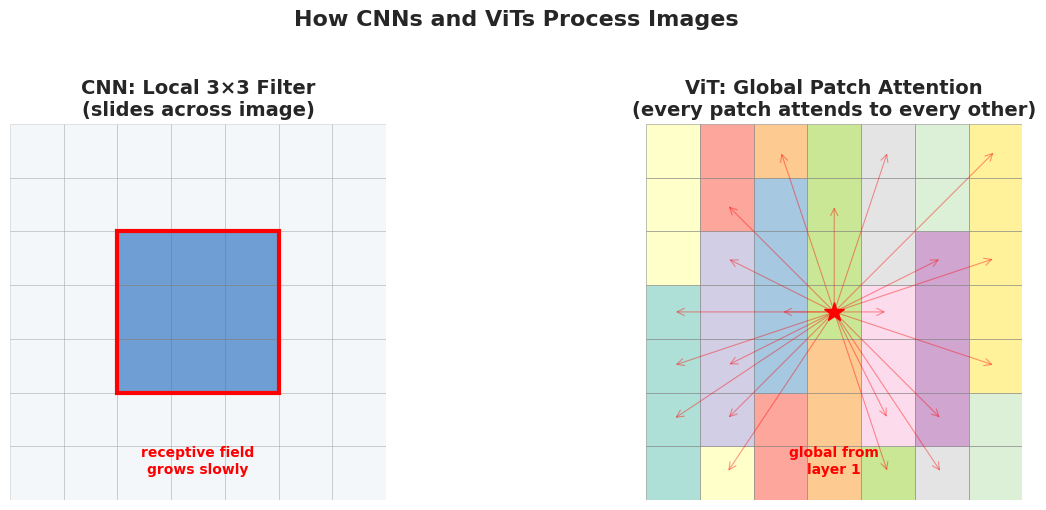

→ Teaching point: CNNs build up context slowly through stacked layers.
  ViTs let every patch talk to every other patch from the very first layer.


In [3]:
# Viz 1 — CNN vs ViT: How they "see" an image
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CNN: local sliding filters
ax = axes[0]
ax.set_xlim(0, 7); ax.set_ylim(0, 7); ax.set_aspect("equal")
for i in range(7):
    for j in range(7):
        color = "#dce6f1" if not (2 <= i <= 4 and 2 <= j <= 4) else "#4a86c8"
        alpha = 0.3 if not (2 <= i <= 4 and 2 <= j <= 4) else 0.8
        rect = plt.Rectangle((i, j), 1, 1, facecolor=color, edgecolor="gray",
                              linewidth=0.5, alpha=alpha)
        ax.add_patch(rect)
highlight = plt.Rectangle((2, 2), 3, 3, facecolor="none", edgecolor="red", linewidth=3)
ax.add_patch(highlight)
ax.set_title("CNN: Local 3×3 Filter\n(slides across image)", fontsize=14, fontweight="bold")
ax.annotate("receptive field\ngrows slowly", xy=(3.5, 0.5), fontsize=10,
            ha="center", color="red", fontweight="bold")
ax.axis("off")

# ViT: global patch attention
ax = axes[1]
ax.set_xlim(0, 7); ax.set_ylim(0, 7); ax.set_aspect("equal")
colors_vit = plt.cm.Set3(np.linspace(0, 1, 49))
for idx, (i, j) in enumerate([(i, j) for i in range(7) for j in range(7)]):
    rect = plt.Rectangle((i, j), 1, 1, facecolor=colors_vit[idx],
                          edgecolor="gray", linewidth=0.5, alpha=0.7)
    ax.add_patch(rect)
center = (3.5, 3.5)
for i in range(7):
    for j in range(7):
        if (i, j) != (3, 3) and np.random.random() > 0.5:
            ax.annotate("", xy=(i + 0.5, j + 0.5), xytext=center,
                        arrowprops=dict(arrowstyle="->", color="red", lw=0.8, alpha=0.4))
ax.plot(*center, "r*", markersize=15, zorder=5)
ax.set_title("ViT: Global Patch Attention\n(every patch attends to every other)", fontsize=14, fontweight="bold")
ax.annotate("global from\nlayer 1", xy=(3.5, 0.5), fontsize=10,
            ha="center", color="red", fontweight="bold")
ax.axis("off")

plt.suptitle("How CNNs and ViTs Process Images", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("→ Teaching point: CNNs build up context slowly through stacked layers.")
print("  ViTs let every patch talk to every other patch from the very first layer.")

---

## Section 2: Data Tour — Radiology Images Meet Text

We use **ROCOv2** (Radiology Objects in COntext v2): ~80,000 radiology images from PubMed Central, each paired with a natural-language caption from the original medical paper. This dataset naturally combines **images** and **text**, making it ideal for both image classification and multimodal learning.

**Why ROCOv2?**
- Real clinical images (CT, MRI, X-ray, ultrasound, …)
- Natural medical captions (not just class labels)
- Supports classification *and* image-text alignment
- Published in *Scientific Data* (2024), freely available

In [4]:
# ── Section 2: Load ROCOv2 Dataset ────────────────────────────────────────────
from datasets import load_dataset

print("Loading ROCOv2 from HuggingFace (this may take a minute on first run)...")
try:
    raw_ds = load_dataset("eltorio/ROCOv2-radiology", split="train")
except Exception:
    print("Primary source unavailable — trying fallback...")
    raw_ds = load_dataset("akahana/rocov2-full", split="train")

print(f"Loaded {len(raw_ds):,} examples")
print(f"Columns: {raw_ds.column_names}")
print(f"\nFirst example keys: {list(raw_ds[0].keys())}")

# ── Extract imaging modality from caption text ──
MODALITY_RULES = {
    "X-ray":       ["x-ray", "xray", "radiograph", "chest film", "plain film"],
    "CT":          ["ct ", "ct,", "ct.", "ct)", "computed tomography", "ct scan"],
    "MRI":         ["mri", "magnetic resonance", "mr image", "t1-weighted",
                    "t2-weighted", "flair", "t1w", "t2w", "dwi"],
    "Ultrasound":  ["ultrasound", "ultrasonograph", "sonograph", "echograph"],
    "Angiography": ["angiogra", "angiogram", "arteriogra"],
    "Mammography": ["mammogra"],
    "PET":         ["pet scan", "pet/ct", "pet-ct", "positron emission"],
    "Fluoroscopy": ["fluoroscop", "barium"],
    "Endoscopy":   ["endoscop", "colonoscop", "gastroscop"],
}

def extract_modality(text):
    text_lower = text.lower()
    for modality, keywords in MODALITY_RULES.items():
        if any(kw in text_lower for kw in keywords):
            return modality
    return "Other"

# Determine which column holds the caption
caption_col = "caption" if "caption" in raw_ds.column_names else raw_ds.column_names[1]
raw_ds = raw_ds.map(lambda x: {"modality": extract_modality(x[caption_col])})

modality_counts = Counter(raw_ds["modality"])
print("\nModality distribution (full dataset):")
for mod, cnt in modality_counts.most_common():
    print(f"  {mod:15s} {cnt:6,d}  ({100*cnt/len(raw_ds):.1f}%)")

Loading ROCOv2 from HuggingFace (this may take a minute on first run)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

data/train-00000-of-00027.parquet:   0%|          | 0.00/497M [00:00<?, ?B/s]

data/train-00001-of-00027.parquet:   0%|          | 0.00/504M [00:00<?, ?B/s]

data/train-00002-of-00027.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00003-of-00027.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
# ── Classroom subset: keep top modalities, sample 4000 train / 800 test ──
TOP_K_CLASSES = 5
top_modalities = [m for m, _ in modality_counts.most_common(TOP_K_CLASSES)]
print(f"Keeping top-{TOP_K_CLASSES} modalities: {top_modalities}")

filtered = raw_ds.filter(lambda x: x["modality"] in top_modalities)
label2id = {m: i for i, m in enumerate(sorted(top_modalities))}
id2label = {i: m for m, i in label2id.items()}
NUM_CLASSES = len(label2id)

filtered = filtered.map(lambda x: {"label": label2id[x["modality"]]})
filtered = filtered.shuffle(seed=SEED)

N_TRAIN, N_TEST = 4000, 800
train_ds = filtered.select(range(min(N_TRAIN, len(filtered))))
test_ds  = filtered.select(range(N_TRAIN, min(N_TRAIN + N_TEST, len(filtered))))

print(f"\nClassroom subset: {len(train_ds)} train, {len(test_ds)} test")
print(f"Classes ({NUM_CLASSES}): {label2id}")

# Quick peek at one example
ex = train_ds[0]
image_col = "image" if "image" in train_ds.column_names else train_ds.column_names[0]
print(f"\nExample caption: {ex[caption_col][:200]}...")
print(f"Modality: {ex['modality']}  |  Label: {ex['label']}")

In [ ]:
# Viz 2 — Image gallery: 4×4 grid with captions (diverse modalities)
sample_indices = []
for lbl in range(NUM_CLASSES):
    idxs = [i for i, x in enumerate(train_ds) if x["label"] == lbl]
    sample_indices.extend(idxs[:3])
sample_indices = sample_indices[:16]
np.random.shuffle(sample_indices)

gallery_imgs = []
gallery_titles = []
for i in sample_indices[:16]:
    ex = train_ds[i]
    img = ex[image_col]
    if not isinstance(img, Image.Image):
        img = Image.open(img).convert("RGB")
    elif img.mode != "RGB":
        img = img.convert("RGB")
    gallery_imgs.append(img)
    cap = ex[caption_col][:80] + "..." if len(ex[caption_col]) > 80 else ex[caption_col]
    gallery_titles.append(f"[{ex['modality']}] {cap}")

show_image_grid(gallery_imgs, gallery_titles, ncols=4, figsize=(18, 14))
print("→ Teaching point: Each image comes with a natural-language caption from its")
print("  medical paper. This pairing of images + text is what enables multimodal learning.")

In [ ]:
# Viz 3 — Imaging modality distribution
fig, ax = plt.subplots(figsize=(10, 5))
labels_list = [id2label[x["label"]] for x in train_ds]
counts = Counter(labels_list)
mods = sorted(counts.keys(), key=lambda m: counts[m], reverse=True)
vals = [counts[m] for m in mods]
colors = sns.color_palette("Set2", len(mods))
bars = ax.bar(mods, vals, color=colors, edgecolor="gray", linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(v), ha="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Imaging Modality"); ax.set_ylabel("Count")
ax.set_title("Class Distribution in Training Set")
plt.tight_layout(); plt.show()

In [ ]:
# Viz 4 — Caption length distribution
cap_lengths = [len(x[caption_col].split()) for x in train_ds]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cap_lengths, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(np.median(cap_lengths), color="coral", linestyle="--", linewidth=2,
           label=f"Median = {np.median(cap_lengths):.0f} words")
ax.set_xlabel("Caption Length (words)"); ax.set_ylabel("Count")
ax.set_title("Distribution of Caption Lengths")
ax.legend(fontsize=12)
plt.tight_layout(); plt.show()
print(f"Caption stats: min={min(cap_lengths)}, max={max(cap_lengths)}, "
      f"mean={np.mean(cap_lengths):.1f}, median={np.median(cap_lengths):.0f}")

In [ ]:
# Viz 5 — Top 25 medical terms in captions
STOP_WORDS = {"the", "a", "an", "of", "in", "and", "is", "to", "with", "was",
              "for", "on", "are", "that", "this", "from", "by", "at", "or", "as",
              "be", "it", "were", "been", "which", "has", "have", "had", "not",
              "but", "its", "can", "also", "into", "than", "no", "our", "their",
              "we", "after", "before", "between", "during", "each", "other", "both",
              "image", "figure", "show", "shows", "showing", "shown", "see", "case"}

all_words = []
for ex in train_ds:
    words = re.findall(r"[a-z]{3,}", ex[caption_col].lower())
    all_words.extend(w for w in words if w not in STOP_WORDS)

word_freq = Counter(all_words).most_common(25)
words_top, freqs_top = zip(*word_freq)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(words_top)), freqs_top, color="steelblue", edgecolor="white")
ax.set_yticks(range(len(words_top)))
ax.set_yticklabels(words_top, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Frequency"); ax.set_title("Top 25 Medical Terms in Captions")
plt.tight_layout(); plt.show()
print("→ Teaching point: The captions are rich in medical terminology — anatomy,")
print("  imaging findings, and diagnoses. This text is what we'll pair with images later.")

---

## Section 3: Image Tokenization — Seeing in Patches

This is the central insight of ViT. Just as NLP models split text into tokens, ViT splits an image into **patches** — fixed-size non-overlapping squares. Each patch becomes a "visual word" that the transformer processes.

For a 224×224 image with 16×16 patches:
- Number of patches = (224 / 16) × (224 / 16) = **14 × 14 = 196 patches**
- Each patch is 16 × 16 × 3 (RGB) = **768 values**
- A linear projection maps these 768 values to an embedding vector

```
224×224 image                     196 patch tokens
┌──┬──┬──┬──┬──┐                ┌───┐
│  │  │  │  │  │   flatten +    │ 1 │ → [768-dim vector]
├──┼──┼──┼──┼──┤   project      │ 2 │ → [768-dim vector]
│  │  │  │  │  │  ──────────→   │...│
├──┼──┼──┼──┼──┤                │196│ → [768-dim vector]
│  │  │  │  │  │                └───┘
└──┴──┴──┴──┴──┘
  14×14 grid                     + [CLS] token at position 0
```

The transformer then sees **197 tokens** (196 patches + 1 CLS token), exactly like processing a 197-word sentence.

In [ ]:
# Viz 6 — Patch grid overlay: see the 14×14 patch boundaries on a real image
demo_img = train_ds[0][image_col]
if not isinstance(demo_img, Image.Image):
    demo_img = Image.open(demo_img)
demo_img = demo_img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
demo_arr = np.array(demo_img)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original image
axes[0].imshow(demo_arr); axes[0].set_title("Original Image (224×224)", fontsize=13)
axes[0].axis("off")

# Image with grid overlay
axes[1].imshow(demo_arr)
for i in range(0, IMG_SIZE + 1, PATCH_SIZE):
    axes[1].axhline(y=i, color="red", linewidth=0.8, alpha=0.7)
    axes[1].axvline(x=i, color="red", linewidth=0.8, alpha=0.7)
axes[1].set_title(f"Patch Grid ({IMG_SIZE//PATCH_SIZE}×{IMG_SIZE//PATCH_SIZE} = {NUM_PATCHES} patches)", fontsize=13)
axes[1].axis("off")

# Numbered patches (first 5×5 corner)
axes[2].imshow(demo_arr[:5*PATCH_SIZE, :5*PATCH_SIZE])
for pi in range(5):
    for pj in range(5):
        y, x = pi * PATCH_SIZE + PATCH_SIZE//2, pj * PATCH_SIZE + PATCH_SIZE//2
        idx = pi * (IMG_SIZE // PATCH_SIZE) + pj
        axes[2].text(x, y, str(idx), ha="center", va="center",
                     fontsize=9, color="yellow", fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.15", facecolor="black", alpha=0.6))
for i in range(0, 5*PATCH_SIZE + 1, PATCH_SIZE):
    axes[2].axhline(y=i, color="red", linewidth=1)
    axes[2].axvline(x=i, color="red", linewidth=1)
axes[2].set_title("Zoomed: Patch Indices (top-left corner)", fontsize=13)
axes[2].axis("off")

plt.suptitle("Step 1: Split Image into Patches", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print(f"→ Each 16×16 patch is one 'token'. The transformer sees {NUM_PATCHES} tokens,")
print(f"  just like processing a {NUM_PATCHES}-word sentence.")

In [ ]:
# Viz 7 — Grid of all 196 individual patches (what each "token" sees)
patches = []
for i in range(0, IMG_SIZE, PATCH_SIZE):
    for j in range(0, IMG_SIZE, PATCH_SIZE):
        patch = demo_arr[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
        patches.append(patch)

grid_h, grid_w = IMG_SIZE // PATCH_SIZE, IMG_SIZE // PATCH_SIZE
fig, axes = plt.subplots(grid_h, grid_w, figsize=(14, 14))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(patches[idx])
    ax.axis("off")

plt.suptitle(f"All {NUM_PATCHES} Patches — Each One Is a 'Visual Token'",
             fontsize=15, fontweight="bold", y=1.01)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()
print("→ Teaching point: Each tiny 16×16 square is all the information one token carries.")
print("  The transformer's job is to integrate information across ALL tokens via attention.")

In [ ]:
# Viz 8 — Patch embedding weights: what does the linear projection learn?
# Load a pretrained ViT and visualize its Conv2d projection filters
from transformers import ViTModel

pretrained_vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
proj_weight = pretrained_vit.embeddings.patch_embeddings.projection.weight.data.cpu()
# proj_weight shape: (768, 3, 16, 16) — 768 filters, each 3×16×16

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for idx, ax in enumerate(axes.flatten()):
    if idx < proj_weight.shape[0]:
        filt = proj_weight[idx].permute(1, 2, 0).numpy()  # (16, 16, 3)
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        ax.imshow(filt)
    ax.axis("off")

plt.suptitle("Learned Patch Embedding Filters (first 32 of 768)\n"
             "Each filter extracts a different visual feature from a 16×16 patch",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("→ These learned filters look like edge detectors, color analyzers, and texture")
print("  extractors — similar to CNN first-layer filters but learned via the ViT objective.")

del pretrained_vit
torch.cuda.empty_cache() if torch.cuda.is_available() else None

### Position Embeddings — Teaching the Transformer About Space

Without position embeddings, the transformer has **no idea** where each patch is in the image. Patch 0 (top-left) and Patch 195 (bottom-right) would look identical structurally.

ViT adds a **learnable position embedding** to each patch token. After training, nearby patches learn similar position embeddings, encoding 2D spatial structure into 1D positional information.

In [ ]:
# Viz 9 — Position embedding similarity heatmap
from transformers import ViTModel

pretrained_vit = ViTModel.from_pretrained("google/vit-base-patch16-224")
pos_embed = pretrained_vit.embeddings.position_embeddings.data.cpu()  # (1, 197, 768)
pos_embed = pos_embed.squeeze(0)  # (197, 768) — includes CLS at position 0

# Cosine similarity between all patch position embeddings (skip CLS)
patch_pos = pos_embed[1:]  # (196, 768)
patch_pos_norm = F.normalize(patch_pos, dim=-1)
sim_matrix = (patch_pos_norm @ patch_pos_norm.T).numpy()  # (196, 196)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full similarity matrix
im = axes[0].imshow(sim_matrix, cmap="RdBu_r", vmin=-0.3, vmax=1.0)
axes[0].set_title("Position Embedding Similarity\n(196 patches × 196 patches)", fontsize=13)
axes[0].set_xlabel("Patch Index"); axes[0].set_ylabel("Patch Index")
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Similarity of one patch to all others, reshaped as 14×14 spatial map
reference_patches = [0, 7, 98, 105, 195]  # corners and center
grid_h = IMG_SIZE // PATCH_SIZE
axes[1].set_title("Similarity to Reference Patches\n(reshaped to 14×14 grid)", fontsize=13)
for k, ref_idx in enumerate([0, 98, 195]):
    sim_map = sim_matrix[ref_idx].reshape(grid_h, grid_h)
    ax_inset = axes[1].inset_axes([k * 0.35, 0.05, 0.3, 0.9])
    ax_inset.imshow(sim_map, cmap="RdBu_r", vmin=-0.3, vmax=1.0)
    row, col = ref_idx // grid_h, ref_idx % grid_h
    ax_inset.plot(col, row, "k*", markersize=12)
    pos_name = ["Top-left", "Center", "Bottom-right"][k]
    ax_inset.set_title(f"Ref: {pos_name}\n(patch {ref_idx})", fontsize=10)
    ax_inset.axis("off")
axes[1].axis("off")

plt.tight_layout(); plt.show()
print("→ Teaching point: Nearby patches learn similar position embeddings, creating a")
print("  smooth 2D spatial map. The model 'knows' where each patch is without being told.")

del pretrained_vit
torch.cuda.empty_cache() if torch.cuda.is_available() else None

In [ ]:
# Viz 10 — Side-by-side: NLP tokenization vs ViT tokenization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# NLP tokenization
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 3); ax.axis("off")
ax.set_title("NLP: Text → Tokens", fontsize=14, fontweight="bold")
sentence = "The chest X-ray shows bilateral opacity"
words = sentence.split()
colors_nlp = plt.cm.Pastel1(np.linspace(0, 0.8, len(words)))
ax.text(5, 2.6, f'"{sentence}"', ha="center", fontsize=11, style="italic")
for i, (w, c) in enumerate(zip(words, colors_nlp)):
    x = 0.5 + i * (9.0 / len(words))
    rect = plt.Rectangle((x, 1.2), 9.0/len(words) - 0.15, 0.7,
                          facecolor=c, edgecolor="gray", linewidth=1)
    ax.add_patch(rect)
    ax.text(x + (9.0/len(words) - 0.15)/2, 1.55, w, ha="center", va="center", fontsize=9)
ax.annotate("", xy=(5, 1.15), xytext=(5, 2.4),
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
ax.text(5, 0.6, "→ Sequence of token embeddings", ha="center", fontsize=11, color="steelblue")

# ViT tokenization
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 3); ax.axis("off")
ax.set_title("ViT: Image → Patch Tokens", fontsize=14, fontweight="bold")
n_show = 7
colors_vit = plt.cm.Set3(np.linspace(0, 0.8, n_show))
# Mini image grid
for i in range(4):
    for j in range(4):
        rect = plt.Rectangle((3.5 + j*0.5, 2.0 + (3-i)*0.25, ), 0.48, 0.23,
                              facecolor=plt.cm.Set3(((i*4+j)/16)),
                              edgecolor="gray", linewidth=0.5)
        ax.add_patch(rect)
ax.annotate("", xy=(5, 1.15), xytext=(5, 1.95),
            arrowprops=dict(arrowstyle="->", color="coral", lw=2))
for i in range(n_show):
    x = 0.8 + i * 1.25
    rect = plt.Rectangle((x, 0.2), 1.1, 0.7,
                          facecolor=colors_vit[i], edgecolor="gray", linewidth=1)
    ax.add_patch(rect)
    ax.text(x + 0.55, 0.55, f"P{i}", ha="center", va="center", fontsize=10)
ax.text(9.5, 0.55, "…", fontsize=14)
ax.text(5, 1.55, "flatten + project each patch", ha="center", fontsize=10, color="coral")

plt.suptitle("The Same Idea: Split Input → Embed → Feed to Transformer",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("→ The transformer doesn't know it's looking at an image. It just sees a sequence")
print("  of vectors, exactly like words. This is why the SAME architecture works for both.")

---

## Section 4: Building a Vision Transformer from Scratch

We now build a complete ViT, piece by piece. The architecture has four main components:

```
┌──────────────────────────────────────────────────────────────────┐
│ 1. PatchEmbedding     — Conv2d splits image into patch vectors  │
│ 2. MultiHeadAttention — Each patch attends to every other patch │
│ 3. TransformerBlock   — Attention + MLP + residual connections  │
│ 4. VisionTransformer  — Stack blocks, add [CLS], classify      │
└──────────────────────────────────────────────────────────────────┘
```

We use a **small model** (256-dim, 6 layers, 8 heads) that trains in minutes on a T4 GPU. The real `google/vit-base` uses 768-dim, 12 layers, 12 heads — same structure, just bigger.

In [ ]:
# ── Building Block 1: Patch Embedding ─────────────────────────────────────────

class PatchEmbedding(nn.Module):
    """Split an image into patches and project each to an embedding vector.

    Uses Conv2d with kernel_size=stride=patch_size — a clean trick that
    performs non-overlapping patch extraction and linear projection in one op.
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=256):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, 3, 224, 224) → (B, embed_dim, 14, 14)
        x = self.proj(x)
        # (B, embed_dim, 14, 14) → (B, 196, embed_dim)
        x = x.flatten(2).transpose(1, 2)
        return x


# Quick test
_pe = PatchEmbedding()
_dummy = torch.randn(2, 3, 224, 224)
print(f"Input:  {_dummy.shape}")
print(f"Output: {_pe(_dummy).shape}  (batch, num_patches={_pe.num_patches}, embed_dim=256)")

In [ ]:
# ── Building Block 2: Multi-Head Self-Attention ──────────────────────────────

class MultiHeadSelfAttention(nn.Module):
    """Standard multi-head self-attention with extractable attention weights.

    We store attention weights so we can visualize them later —
    which patches attend to which other patches?
    """
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)
        self.attn_weights = None

    def forward(self, x):
        B, N, C = x.shape
        # Compute Q, K, V in one matrix multiply
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        self.attn_weights = attn.detach()
        attn = self.attn_drop(attn)

        # Apply attention to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x


# Quick test
_mhsa = MultiHeadSelfAttention(embed_dim=256, num_heads=8)
_tokens = torch.randn(2, 197, 256)
print(f"Input:  {_tokens.shape}")
print(f"Output: {_mhsa(_tokens).shape}")
print(f"Attention weights: {_mhsa.attn_weights.shape}  (batch, heads, seq, seq)")

In [ ]:
# ── Building Block 3: Transformer Block ──────────────────────────────────────

class TransformerBlock(nn.Module):
    """Pre-norm transformer block: LN → MHSA → residual → LN → MLP → residual.

    This is identical to a standard transformer encoder block. The same block
    is used in BERT, GPT, and now ViT — only the input tokenization differs.
    """
    def __init__(self, embed_dim=256, num_heads=8, mlp_ratio=2.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# ── Building Block 4: Full Vision Transformer ───────────────────────────────

class VisionTransformer(nn.Module):
    """Complete Vision Transformer for image classification."""
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 num_classes=5, embed_dim=256, num_heads=8,
                 num_layers=6, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                          # (B, 196, embed_dim)
        cls = self.cls_token.expand(B, -1, -1)            # (B, 1, embed_dim)
        x = torch.cat([cls, x], dim=1)                    # (B, 197, embed_dim)
        x = self.pos_drop(x + self.pos_embed)             # Add position info
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.head(x[:, 0])                          # Classify via [CLS]

    @torch.no_grad()
    def get_attention_maps(self, x):
        """Forward pass that collects attention maps from every layer."""
        B = x.shape[0]
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed
        maps = []
        for block in self.blocks:
            x = block(x)
            maps.append(block.attn.attn_weights)
        return maps


# Instantiate
model = VisionTransformer(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES, embed_dim=256,
    num_heads=8, num_layers=6, mlp_ratio=2.0, dropout=0.1,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ViT from scratch: {total_params:,} total parameters ({trainable_params:,} trainable)")
print(f"  Embedding dim: 256 | Heads: 8 | Layers: 6 | MLP ratio: 2.0")
print(f"  Patches: {NUM_PATCHES} | Sequence length: {NUM_PATCHES + 1} (with [CLS])")

In [ ]:
# Viz 11 — Parameter distribution by component
component_params = {
    "Patch Embedding\n(Conv2d)": sum(p.numel() for p in model.patch_embed.parameters()),
    "CLS Token +\nPosition Embed": model.cls_token.numel() + model.pos_embed.numel(),
    "Transformer\nBlocks (×6)": sum(p.numel() for p in model.blocks.parameters()),
    "Layer Norm": sum(p.numel() for p in model.norm.parameters()),
    "Classification\nHead": sum(p.numel() for p in model.head.parameters()),
}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(component_params.keys())
values = list(component_params.values())
colors = ["#4a86c8", "#6ab04c", "#e17055", "#a29bfe", "#fd79a8"]
bars = ax.bar(names, [v/1000 for v in values], color=colors, edgecolor="gray", linewidth=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{v:,}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Parameters (thousands)")
ax.set_title(f"Parameter Distribution — ViT-Small ({total_params:,} total)", fontsize=14)
plt.tight_layout(); plt.show()
print("→ Most parameters live in the Transformer blocks (attention + MLP).")
print("  The patch embedding and classification head are comparatively tiny.")

In [ ]:
# ── Prepare PyTorch DataLoaders ───────────────────────────────────────────────
from torch.utils.data import Dataset, DataLoader

class ROCOImageDataset(Dataset):
    """Wraps a HuggingFace dataset for PyTorch DataLoader."""
    def __init__(self, hf_dataset, transform, image_col, caption_col):
        self.ds = hf_dataset
        self.transform = transform
        self.image_col = image_col
        self.caption_col = caption_col

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]
        img = ex[self.image_col]
        if not isinstance(img, Image.Image):
            img = Image.open(img)
        img = img.convert("RGB")
        img = self.transform(img)
        label = ex["label"]
        caption = ex[self.caption_col]
        return img, label, caption


train_dataset = ROCOImageDataset(train_ds, train_transform, image_col, caption_col)
test_dataset  = ROCOImageDataset(test_ds, val_transform, image_col, caption_col)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs, labels, caps = next(iter(train_loader))
print(f"Batch shapes — images: {imgs.shape}, labels: {labels.shape}")
print(f"Sample caption: {caps[0][:100]}...")

In [ ]:
# ── Train the ViT from scratch ────────────────────────────────────────────────
NUM_EPOCHS = 25

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

train_losses, val_accs = [], []

if not USE_PRECOMPUTED:
    for epoch in range(NUM_EPOCHS):
        # ── Training ──
        model.train()
        epoch_loss = 0
        for images, labels, _ in train_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        # ── Validation ──
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels, _ in test_loader:
                images, labels = images.to(device), labels.to(device)
                preds = model(images).argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.shape[0]
        val_accs.append(correct / total)
        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS}  "
                  f"loss={train_losses[-1]:.4f}  val_acc={val_accs[-1]:.3f}")

    torch.save(model.state_dict(), "vit_from_scratch.pt")
    print("\nModel saved to vit_from_scratch.pt")
else:
    model.load_state_dict(torch.load("vit_from_scratch.pt", map_location=device))
    print("Loaded precomputed model from vit_from_scratch.pt")

In [ ]:
# Viz 12 — Training curves: loss + validation accuracy
if train_losses and val_accs:
    plot_training_curves(train_losses, val_accs, metric_name="Accuracy")
    print(f"Final — loss: {train_losses[-1]:.4f}, val accuracy: {val_accs[-1]:.3f}")
else:
    print("(Skipped — using precomputed model)")

In [ ]:
# Viz 13 — Confusion matrix for the from-scratch ViT
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

scratch_acc = accuracy_score(all_labels, all_preds)
scratch_f1  = f1_score(all_labels, all_preds, average="macro")
print(f"From-scratch ViT — Accuracy: {scratch_acc:.3f}  Macro-F1: {scratch_f1:.3f}")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[id2label[i] for i in range(NUM_CLASSES)],
            yticklabels=[id2label[i] for i in range(NUM_CLASSES)], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — ViT from Scratch\n(Accuracy: {scratch_acc:.3f})", fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Viz 14 — Multi-head attention maps: what does each head look at?
model.eval()
sample_imgs, sample_labels, _ = next(iter(test_loader))
sample_imgs = sample_imgs[:3].to(device)

attn_maps = model.get_attention_maps(sample_imgs)
# attn_maps: list of (B, heads, 197, 197) — one per layer
last_layer_attn = attn_maps[-1].cpu()  # (B, 8, 197, 197)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
grid_h = IMG_SIZE // PATCH_SIZE

for row in range(3):
    # CLS token attention to patches for 4 different heads
    for col in range(4):
        head_idx = col * 2  # show heads 0, 2, 4, 6
        cls_attn = last_layer_attn[row, head_idx, 0, 1:]  # CLS→patches
        cls_attn = cls_attn.reshape(grid_h, grid_h).numpy()

        ax = axes[row, col]
        # Show original image underneath
        orig_img = unnormalize(sample_imgs[row].cpu())
        orig_img = orig_img.permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(orig_img, alpha=0.3)
        ax.imshow(cls_attn, cmap="hot", alpha=0.7,
                  extent=[0, IMG_SIZE, IMG_SIZE, 0])
        if row == 0:
            ax.set_title(f"Head {head_idx}", fontsize=13, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"Image {row+1}\n[{id2label[sample_labels[row].item()]}]",
                          fontsize=11)
        ax.axis("off")

plt.suptitle("[CLS] Token Attention — Last Layer (4 of 8 Heads)\nBrighter = more attention",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("→ Teaching point: Different heads learn to attend to different regions.")
print("  Some focus on edges, some on central structures, some on background.")

In [ ]:
# Viz 15 — [CLS] attention overlay: average across all heads
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    cls_attn_avg = last_layer_attn[i, :, 0, 1:].mean(dim=0)  # avg over heads
    cls_attn_map = cls_attn_avg.reshape(grid_h, grid_h).numpy()
    cls_attn_map = (cls_attn_map - cls_attn_map.min()) / (cls_attn_map.max() - cls_attn_map.min() + 1e-8)

    orig_img = unnormalize(sample_imgs[i].cpu()).permute(1, 2, 0).clamp(0, 1).numpy()
    # Resize attention map to image size
    attn_resized = np.array(Image.fromarray((cls_attn_map * 255).astype(np.uint8)).resize(
        (IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0

    axes[i].imshow(orig_img)
    axes[i].imshow(attn_resized, cmap="jet", alpha=0.5)
    axes[i].set_title(f"{id2label[sample_labels[i].item()]}", fontsize=13, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Where Does the Model Look? ([CLS] Attention, All Heads Averaged)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("→ Even our small from-scratch model learns to focus on image-relevant regions.")

---

## Section 5: Pre-trained ViT and Transfer Learning

Training from scratch requires **lots of data** and **lots of compute**. In practice, we almost always start from a pretrained model and adapt it to our task. This is the same transfer learning recipe from the genomics workshop:

```
Approach 1: Frozen Embeddings + Linear Probe
  Pretrained ViT (frozen) ──→ CLS embedding ──→ Logistic Regression

Approach 2: LoRA Fine-Tuning
  Pretrained ViT (mostly frozen) ──→ LoRA adapters on attention ──→ Trainer
```

We use `google/vit-base-patch16-224` (86M parameters, pretrained on ImageNet-21k), compared to our from-scratch model (~3M parameters trained on 4,000 images). The difference in pretrained knowledge is enormous.

In [ ]:
# ── Load pretrained ViT and extract frozen embeddings ─────────────────────────
from transformers import ViTModel, ViTImageProcessor

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
pretrained_vit = ViTModel.from_pretrained("google/vit-base-patch16-224").to(device)
pretrained_vit.eval()

pt_params = sum(p.numel() for p in pretrained_vit.parameters())
print(f"Pretrained ViT-Base: {pt_params:,} parameters")
print(f"  vs. our from-scratch: {total_params:,} parameters")
print(f"  Ratio: {pt_params / total_params:.1f}x larger\n")

@torch.no_grad()
def extract_vit_embeddings(model, processor, dataset, image_col, batch_size=32):
    """Extract [CLS] token embeddings from pretrained ViT."""
    model.eval()
    all_embs, all_labels = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset.select(range(i, min(i + batch_size, len(dataset))))
        images = []
        for ex in batch:
            img = ex[image_col]
            if not isinstance(img, Image.Image):
                img = Image.open(img)
            images.append(img.convert("RGB"))
        inputs = processor(images=images, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls_emb = outputs.last_hidden_state[:, 0]  # [CLS] token
        all_embs.append(cls_emb.cpu())
        all_labels.extend([ex["label"] for ex in batch])
    return torch.cat(all_embs, dim=0), torch.tensor(all_labels)

if not USE_PRECOMPUTED:
    print("Extracting frozen embeddings (this takes ~2 minutes)...")
    train_embs, train_labels = extract_vit_embeddings(
        pretrained_vit, processor, train_ds, image_col)
    test_embs, test_labels = extract_vit_embeddings(
        pretrained_vit, processor, test_ds, image_col)
    torch.save({"train_embs": train_embs, "train_labels": train_labels,
                "test_embs": test_embs, "test_labels": test_labels},
               "frozen_embeddings.pt")
    print(f"Done! Train: {train_embs.shape}, Test: {test_embs.shape}")
else:
    data = torch.load("frozen_embeddings.pt", map_location="cpu")
    train_embs, train_labels = data["train_embs"], data["train_labels"]
    test_embs, test_labels = data["test_embs"], data["test_labels"]
    print(f"Loaded precomputed embeddings — Train: {train_embs.shape}")

In [ ]:
# ── Linear probe on frozen embeddings ─────────────────────────────────────────
lr_clf = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced", random_state=SEED)
lr_clf.fit(train_embs.numpy(), train_labels.numpy())
frozen_preds = lr_clf.predict(test_embs.numpy())

frozen_acc = accuracy_score(test_labels.numpy(), frozen_preds)
frozen_f1  = f1_score(test_labels.numpy(), frozen_preds, average="macro")
print(f"Frozen ViT + Linear Probe — Accuracy: {frozen_acc:.3f}  Macro-F1: {frozen_f1:.3f}")
print(f"  (vs. from-scratch ViT:   Accuracy: {scratch_acc:.3f}  Macro-F1: {scratch_f1:.3f})")
print(f"\n→ Just using frozen embeddings + logistic regression already beats training from scratch!")

In [ ]:
# ── LoRA fine-tuning ──────────────────────────────────────────────────────────
from transformers import ViTForImageClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, TaskType

# Load ViT with a classification head
lora_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# Apply LoRA: only train small rank-decomposition matrices on attention layers
lora_config = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"],  # also train the new classification head
)
lora_model = get_peft_model(lora_model, lora_config)
lora_model.print_trainable_parameters()

del pretrained_vit
torch.cuda.empty_cache() if torch.cuda.is_available() else None

In [ ]:
# Viz 16 — Parameter comparison: full model vs LoRA trainable
full_params = sum(p.numel() for p in lora_model.parameters())
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
frozen = full_params - trainable

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["Frozen Parameters", "LoRA Trainable"],
              [frozen / 1e6, trainable / 1e6],
              color=["#a0c4e8", "coral"], edgecolor="gray", linewidth=0.5)
for bar, val in zip(bars, [frozen, trainable]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:,}\n({100*val/full_params:.1f}%)",
            ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Parameters (millions)")
ax.set_title("LoRA Fine-Tuning: We Train <1% of Parameters", fontsize=14)
plt.tight_layout(); plt.show()
print(f"→ LoRA trains only {trainable:,} out of {full_params:,} parameters ({100*trainable/full_params:.1f}%)")
print(f"  The W = W₀ + (α/r)·B·A decomposition keeps most weights frozen.")

In [ ]:
# ── Prepare HF dataset for Trainer ────────────────────────────────────────────
from datasets import Dataset as HFDataset

def preprocess_for_trainer(examples):
    """Process images through the ViT processor for HF Trainer."""
    images = []
    for img in examples[image_col]:
        if not isinstance(img, Image.Image):
            img = Image.open(img)
        images.append(img.convert("RGB"))
    inputs = processor(images=images, return_tensors="pt")
    inputs["labels"] = examples["label"]
    return inputs

train_hf = train_ds.with_transform(preprocess_for_trainer)
test_hf  = test_ds.with_transform(preprocess_for_trainer)

# ── Train with LoRA ──
training_args = TrainingArguments(
    output_dir="./vit_lora_adapter",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    warmup_ratio=0.1,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
    seed=SEED,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

if not USE_PRECOMPUTED:
    trainer = Trainer(
        model=lora_model,
        args=training_args,
        train_dataset=train_hf,
        eval_dataset=test_hf,
        compute_metrics=compute_metrics,
    )
    train_result = trainer.train()
    lora_model.save_pretrained("./vit_lora_adapter")
    print("LoRA adapter saved to ./vit_lora_adapter")
else:
    from peft import PeftModel
    lora_model = PeftModel.from_pretrained(
        ViTForImageClassification.from_pretrained(
            "google/vit-base-patch16-224", num_labels=NUM_CLASSES,
            ignore_mismatched_sizes=True),
        "./vit_lora_adapter"
    )
    print("Loaded precomputed LoRA adapter")

In [ ]:
# Viz 17 — LoRA fine-tuning loss curve
if not USE_PRECOMPUTED and hasattr(trainer, "state"):
    log_history = trainer.state.log_history
    train_steps = [e["step"] for e in log_history if "loss" in e]
    train_loss_vals = [e["loss"] for e in log_history if "loss" in e]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train_steps, train_loss_vals, linewidth=2, color="steelblue")
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.set_title("LoRA Fine-Tuning Loss")
    plt.tight_layout(); plt.show()

# Evaluate LoRA model
lora_model.eval().to(device)
lora_preds, lora_labels_list = [], []
with torch.no_grad():
    for i in range(0, len(test_ds), 32):
        batch = test_ds.select(range(i, min(i + 32, len(test_ds))))
        images = []
        for ex in batch:
            img = ex[image_col]
            if not isinstance(img, Image.Image):
                img = Image.open(img)
            images.append(img.convert("RGB"))
        inputs = processor(images=images, return_tensors="pt").to(device)
        logits = lora_model(**inputs).logits
        lora_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        lora_labels_list.extend([ex["label"] for ex in batch])

lora_acc = accuracy_score(lora_labels_list, lora_preds)
lora_f1  = f1_score(lora_labels_list, lora_preds, average="macro")
print(f"LoRA ViT — Accuracy: {lora_acc:.3f}  Macro-F1: {lora_f1:.3f}")

In [ ]:
# Viz 18 — t-SNE of frozen vs LoRA embeddings
# Extract LoRA embeddings
lora_base = lora_model.base_model.model if hasattr(lora_model, "base_model") else lora_model

@torch.no_grad()
def extract_lora_embeddings(model, processor, dataset, image_col, batch_size=32):
    model.eval()
    all_embs, all_labels = [], []
    for i in range(0, len(dataset), batch_size):
        batch = dataset.select(range(i, min(i + batch_size, len(dataset))))
        images = []
        for ex in batch:
            img = ex[image_col]
            if not isinstance(img, Image.Image):
                img = Image.open(img)
            images.append(img.convert("RGB"))
        inputs = processor(images=images, return_tensors="pt").to(device)
        outputs = model(**inputs, output_hidden_states=True)
        cls_emb = outputs.hidden_states[-1][:, 0]
        all_embs.append(cls_emb.cpu())
        all_labels.extend([ex["label"] for ex in batch])
    return torch.cat(all_embs, dim=0), torch.tensor(all_labels)

lora_embs, lora_test_labels = extract_lora_embeddings(
    lora_model, processor, test_ds, image_col)

# t-SNE for both
n_plot = min(500, len(test_embs))
idx = np.random.choice(len(test_embs), n_plot, replace=False)

tsne_frozen = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(
    test_embs[idx].numpy())
tsne_lora = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(
    lora_embs[idx].numpy())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors_map = sns.color_palette("Set2", NUM_CLASSES)

for c in range(NUM_CLASSES):
    mask = test_labels[idx].numpy() == c
    ax1.scatter(tsne_frozen[mask, 0], tsne_frozen[mask, 1],
                c=[colors_map[c]], label=id2label[c], alpha=0.6, s=20)
    ax2.scatter(tsne_lora[mask, 0], tsne_lora[mask, 1],
                c=[colors_map[c]], label=id2label[c], alpha=0.6, s=20)

ax1.set_title("Frozen ViT Embeddings (t-SNE)", fontsize=13)
ax1.legend(fontsize=9, loc="best")
ax2.set_title("LoRA Fine-tuned Embeddings (t-SNE)", fontsize=13)
ax2.legend(fontsize=9, loc="best")
for ax in [ax1, ax2]:
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")

plt.suptitle("How LoRA Reshapes the Embedding Space", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("→ Teaching point: LoRA fine-tuning creates tighter, more separable clusters.")
print("  The model learns to organize its representations around the task at hand.")

In [ ]:
# Viz 19 — Model comparison: from-scratch vs frozen vs LoRA
results = {
    "From-Scratch ViT\n(3M params, 25 epochs)":  (scratch_acc, scratch_f1),
    "Frozen ViT + LinProbe\n(0 trainable in ViT)": (frozen_acc, frozen_f1),
    "LoRA ViT\n(<1% trainable)":                   (lora_acc, lora_f1),
}

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results))
width = 0.35
accs = [v[0] for v in results.values()]
f1s  = [v[1] for v in results.values()]

bars1 = ax.bar(x - width/2, accs, width, label="Accuracy", color="steelblue", edgecolor="gray")
bars2 = ax.bar(x + width/2, f1s,  width, label="Macro-F1", color="coral", edgecolor="gray")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(list(results.keys()), fontsize=11)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison: From-Scratch → Frozen → LoRA", fontsize=14, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout(); plt.show()

display_comparison_table(
    [[name.replace("\n", " "), f"{acc:.3f}", f"{f1:.3f}"]
     for name, (acc, f1) in results.items()],
    ["Model", "Accuracy", "Macro-F1"],
    title="Summary of All Approaches"
)
print("→ Transfer learning is enormously powerful: a frozen pretrained model with a")
print("  simple linear probe often outperforms training from scratch with limited data.")

---

## Section 6: Multimodal — From ViT to Vision-Language Models

So far, our ViT processes images alone. But the ROCOv2 dataset has **captions** — natural language descriptions of each image. Can we teach a model to understand *both* modalities?

This is exactly what **CLIP** (Contrastive Language-Image Pre-training) does:

```
┌────────────────────────────────────────────────────────────┐
│                     CLIP Architecture                       │
│                                                             │
│   Image ──→ [ViT Encoder] ──→ image embedding ──┐          │
│                                                   │ cosine  │
│                                                   │ similar │
│   Text  ──→ [Text Encoder] ──→ text embedding ──┘          │
│                                                             │
│   Training: matching pairs should be similar,               │
│             non-matching pairs should be dissimilar          │
│             (contrastive loss / InfoNCE)                     │
└────────────────────────────────────────────────────────────┘
```

### From CLIP to Generation

CLIP is *discriminative* (it matches images to text). But it opens the door to *generative* models:

| Model | Architecture | Task |
|---|---|---|
| **CLIP** | ViT + Text Encoder | Image-text matching (discriminative) |
| **Image Captioning** | ViT encoder → Text decoder | Generate text from images |
| **Stable Diffusion** | Text encoder → U-Net (+ ViT) → Image | Generate images from text |
| **LLaVA / GPT-4V** | ViT + LLM | Multimodal conversation |

The ViT we built is the **image encoder** in all of these systems. Learning vision-language alignment is the bridge to multimodal AI.

In [ ]:
# ── Build a simple contrastive model (mini-CLIP) on our dataset ───────────────
from transformers import AutoTokenizer, AutoModel

# Use a small text encoder (distilbert) for the text side
text_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
text_encoder = AutoModel.from_pretrained("distilbert-base-uncased").to(device)
for p in text_encoder.parameters():
    p.requires_grad = False  # freeze text encoder

class SimpleCLIP(nn.Module):
    """Minimal contrastive image-text model.
    Projects image and text embeddings into a shared space and computes
    InfoNCE loss to align matching pairs.
    """
    def __init__(self, img_dim=768, text_dim=768, proj_dim=256):
        super().__init__()
        self.image_proj = nn.Sequential(
            nn.Linear(img_dim, proj_dim),
            nn.GELU(),
            nn.Linear(proj_dim, proj_dim),
        )
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, proj_dim),
            nn.GELU(),
            nn.Linear(proj_dim, proj_dim),
        )
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def forward(self, img_emb, text_emb):
        img_proj = F.normalize(self.image_proj(img_emb), dim=-1)
        text_proj = F.normalize(self.text_proj(text_emb), dim=-1)
        logit_scale = self.logit_scale.exp()
        logits = logit_scale * img_proj @ text_proj.T
        return logits

clip_model = SimpleCLIP(img_dim=768, text_dim=768, proj_dim=256).to(device)
clip_optimizer = torch.optim.AdamW(clip_model.parameters(), lr=1e-3, weight_decay=0.01)

print(f"Simple CLIP model: {sum(p.numel() for p in clip_model.parameters()):,} parameters")
print("Image encoder: frozen pretrained ViT | Text encoder: frozen DistilBERT")

In [ ]:
# ── Train contrastive model on image-caption pairs ────────────────────────────

@torch.no_grad()
def encode_texts(tokenizer, encoder, texts, device, max_length=128):
    """Encode a batch of texts using the frozen text encoder."""
    enc = tokenizer(texts, return_tensors="pt", padding=True,
                    truncation=True, max_length=max_length).to(device)
    out = encoder(**enc)
    return out.last_hidden_state[:, 0]  # [CLS] token

clip_losses = []
CLIP_EPOCHS = 15
CLIP_BATCH = 32

if not USE_PRECOMPUTED:
    print(f"Training contrastive model for {CLIP_EPOCHS} epochs...")
    for epoch in range(CLIP_EPOCHS):
        clip_model.train()
        epoch_loss = 0
        n_batches = 0
        indices = np.random.permutation(len(train_ds))

        for start in range(0, len(train_ds) - CLIP_BATCH, CLIP_BATCH):
            batch_idx = indices[start:start + CLIP_BATCH]
            batch = train_ds.select(batch_idx.tolist())

            # Get image embeddings from frozen ViT
            img_embs = train_embs[batch_idx].to(device)

            # Get text embeddings from frozen text encoder
            captions = [ex[caption_col][:200] for ex in batch]
            text_embs = encode_texts(text_tokenizer, text_encoder, captions, device)

            # Contrastive loss (symmetric InfoNCE)
            logits = clip_model(img_embs, text_embs)
            targets = torch.arange(len(logits), device=device)
            loss_i2t = F.cross_entropy(logits, targets)
            loss_t2i = F.cross_entropy(logits.T, targets)
            loss = (loss_i2t + loss_t2i) / 2

            clip_optimizer.zero_grad()
            loss.backward()
            clip_optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        clip_losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{CLIP_EPOCHS}  loss={avg_loss:.4f}")

    torch.save(clip_model.state_dict(), "contrastive_model.pt")
else:
    clip_model.load_state_dict(torch.load("contrastive_model.pt", map_location=device))
    print("Loaded precomputed contrastive model")

In [ ]:
# Viz 20 — Contrastive training loss
if clip_losses:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(clip_losses, linewidth=2, color="steelblue", marker="o", markersize=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("InfoNCE Loss")
    ax.set_title("Contrastive Learning Loss (Image-Text Alignment)")
    plt.tight_layout(); plt.show()

# Viz 21 — Image-text similarity matrix
clip_model.eval()
N_VIZ = 8
viz_batch = test_ds.select(range(N_VIZ))
viz_img_embs = test_embs[:N_VIZ].to(device)
viz_captions = [ex[caption_col][:100] for ex in viz_batch]
viz_text_embs = encode_texts(text_tokenizer, text_encoder, viz_captions, device)

with torch.no_grad():
    img_proj = F.normalize(clip_model.image_proj(viz_img_embs), dim=-1)
    text_proj = F.normalize(clip_model.text_proj(viz_text_embs), dim=-1)
    sim_matrix = (img_proj @ text_proj.T).cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 8))
short_caps = [c[:50] + "..." if len(c) > 50 else c for c in viz_captions]
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0)
ax.set_xticks(range(N_VIZ)); ax.set_yticks(range(N_VIZ))
ax.set_xticklabels([f"Text {i}" for i in range(N_VIZ)], rotation=45, ha="right", fontsize=9)
ax.set_yticklabels([f"Img {i} [{viz_batch[i]['modality']}]" for i in range(N_VIZ)], fontsize=9)
for i in range(N_VIZ):
    for j in range(N_VIZ):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if sim_matrix[i,j] > 0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Image-Text Similarity Matrix\n(diagonal = matching pairs should be highest)",
             fontsize=14)
plt.tight_layout(); plt.show()
print("→ A well-trained contrastive model shows high similarity on the diagonal (matching")
print("  image-caption pairs) and low similarity off-diagonal (mismatched pairs).")

### BiomedCLIP: A Production-Scale Medical Vision-Language Model

Our simple contrastive model above demonstrates the *idea*. In practice, Microsoft trained **BiomedCLIP** on 15 million medical image-caption pairs from PubMed Central. It uses:
- **ViT-B/16** as the image encoder (the same architecture we built!)
- **PubMedBERT** as the text encoder (trained on biomedical text)

Let's see what a production medical CLIP model can do.

In [ ]:
# ── Load BiomedCLIP ───────────────────────────────────────────────────────────
import open_clip

biomed_model, _, biomed_preprocess = open_clip.create_model_and_transforms(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
biomed_tokenizer = open_clip.get_tokenizer(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
biomed_model = biomed_model.eval().to(device)

biomed_params = sum(p.numel() for p in biomed_model.parameters())
print(f"BiomedCLIP: {biomed_params:,} parameters")
print("  Image encoder: ViT-B/16 (same architecture as google/vit-base)")
print("  Text encoder: PubMedBERT")
print("  Trained on: 15M medical figure-caption pairs from PMC")

In [ ]:
# ── Zero-shot classification with BiomedCLIP ─────────────────────────────────
# Classify images using text prompts — NO training on our dataset at all!

text_prompts = {mod: f"a {mod.lower()} medical image" for mod in sorted(top_modalities)}
text_prompts.update({
    "X-ray": "a chest x-ray radiograph",
    "CT": "a CT scan computed tomography image",
    "MRI": "an MRI magnetic resonance image",
    "Ultrasound": "an ultrasound sonography image",
})

print("Zero-shot text prompts:")
for mod, prompt in text_prompts.items():
    print(f"  {mod:15s} → \"{prompt}\"")

prompt_list = [text_prompts[id2label[i]] for i in range(NUM_CLASSES)]
text_tokens = biomed_tokenizer(prompt_list).to(device)

with torch.no_grad():
    text_features = biomed_model.encode_text(text_tokens)
    text_features = F.normalize(text_features, dim=-1)

# Classify test images
zs_preds, zs_labels = [], []
for i in range(0, len(test_ds), 32):
    batch = test_ds.select(range(i, min(i + 32, len(test_ds))))
    images = []
    for ex in batch:
        img = ex[image_col]
        if not isinstance(img, Image.Image):
            img = Image.open(img)
        images.append(biomed_preprocess(img.convert("RGB")))
    img_tensor = torch.stack(images).to(device)

    with torch.no_grad():
        img_features = biomed_model.encode_image(img_tensor)
        img_features = F.normalize(img_features, dim=-1)
        sims = img_features @ text_features.T
        preds = sims.argmax(dim=-1).cpu().numpy()

    zs_preds.extend(preds)
    zs_labels.extend([ex["label"] for ex in batch])

zs_acc = accuracy_score(zs_labels, zs_preds)
zs_f1  = f1_score(zs_labels, zs_preds, average="macro")
print(f"\nBiomedCLIP Zero-Shot — Accuracy: {zs_acc:.3f}  Macro-F1: {zs_f1:.3f}")
print("→ This model has NEVER seen our dataset or labels, yet it classifies using text alone!")

In [ ]:
# Viz 22 — Zero-shot confusion matrix
cm_zs = confusion_matrix(zs_labels, zs_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_zs, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[id2label[i] for i in range(NUM_CLASSES)],
            yticklabels=[id2label[i] for i in range(NUM_CLASSES)], ax=ax)
ax.set_xlabel("Predicted (via text prompt)"); ax.set_ylabel("True")
ax.set_title(f"BiomedCLIP Zero-Shot Classification\n(Accuracy: {zs_acc:.3f} — no training!)",
             fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Viz 23 — Image-text retrieval: "Google search" for medical images using text
retrieval_queries = [
    "chest x-ray showing lung opacity",
    "brain MRI with contrast enhancement",
    "abdominal CT scan showing liver",
]

# Encode all test images with BiomedCLIP
all_test_img_features = []
for i in range(0, len(test_ds), 32):
    batch = test_ds.select(range(i, min(i + 32, len(test_ds))))
    images = []
    for ex in batch:
        img = ex[image_col]
        if not isinstance(img, Image.Image):
            img = Image.open(img)
        images.append(biomed_preprocess(img.convert("RGB")))
    img_tensor = torch.stack(images).to(device)
    with torch.no_grad():
        feats = biomed_model.encode_image(img_tensor)
        feats = F.normalize(feats, dim=-1)
    all_test_img_features.append(feats.cpu())
all_test_img_features = torch.cat(all_test_img_features, dim=0)

fig, axes = plt.subplots(len(retrieval_queries), 6, figsize=(20, 4 * len(retrieval_queries)))

for q_idx, query in enumerate(retrieval_queries):
    # Encode query text
    query_tokens = biomed_tokenizer([query]).to(device)
    with torch.no_grad():
        query_feat = biomed_model.encode_text(query_tokens)
        query_feat = F.normalize(query_feat, dim=-1).cpu()

    # Find top-5 most similar images
    sims = (all_test_img_features @ query_feat.T).squeeze()
    top5 = sims.topk(5).indices.numpy()

    axes[q_idx, 0].text(0.5, 0.5, f'Query:\n"{query}"',
                         ha="center", va="center", fontsize=11,
                         fontweight="bold", wrap=True,
                         transform=axes[q_idx, 0].transAxes)
    axes[q_idx, 0].axis("off")

    for k, idx in enumerate(top5):
        ex = test_ds[int(idx)]
        img = ex[image_col]
        if not isinstance(img, Image.Image):
            img = Image.open(img)
        img = img.convert("RGB")
        axes[q_idx, k+1].imshow(img)
        axes[q_idx, k+1].set_title(f"#{k+1} [{ex['modality']}]\nsim={sims[idx]:.3f}",
                                    fontsize=9)
        axes[q_idx, k+1].axis("off")

plt.suptitle("Image-Text Retrieval: Find Images by Describing Them in Words",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("→ Teaching point: The same ViT we built from scratch is now the image encoder in a")
print("  model that understands BOTH images AND text. This is how foundation models become")
print("  multimodal — and the bridge to generative models (captioning, text-to-image).")

---

## Section 7: Interpretation — What Does ViT See?

Understanding *what* a model attends to is critical in medical imaging, where the stakes are high. Two key interpretation techniques for ViT:

1. **Attention Rollout** — Combine attention maps across all layers to see the total information flow from input patches to the CLS token. This accounts for the residual connections that mix attention across layers.

2. **Layer-by-Layer Attention** — Visualize how attention patterns change from early layers (local features) to later layers (global semantic understanding).

**Caveat:** Attention maps show where the model *looks*, not necessarily what it *uses* for its decision. Attention ≠ importance (the same caveat applies to saliency in the genomics workshop).

In [ ]:
# ── Attention rollout from pretrained ViT ──────────────────────────────────────
from transformers import ViTModel

interp_vit = ViTModel.from_pretrained("google/vit-base-patch16-224",
                                       output_attentions=True).to(device).eval()

def attention_rollout(attentions):
    """Compute attention rollout across all layers.
    Accounts for residual connections by mixing identity with attention.
    """
    result = torch.eye(attentions[0].shape[-1]).to(attentions[0].device)
    for attn in attentions:
        attn_heads_mean = attn.mean(dim=1).squeeze(0)  # avg over heads
        attn_with_residual = 0.5 * attn_heads_mean + 0.5 * torch.eye(
            attn_heads_mean.shape[-1], device=attn.device)
        attn_with_residual = attn_with_residual / attn_with_residual.sum(dim=-1, keepdim=True)
        result = attn_with_residual @ result
    return result

# Get 3 diverse sample images
sample_indices_interp = []
for c in range(min(3, NUM_CLASSES)):
    for i, ex in enumerate(test_ds):
        if ex["label"] == c:
            sample_indices_interp.append(i)
            break

# Viz 24 — Attention rollout on 3 sample images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
grid_h = IMG_SIZE // PATCH_SIZE

for col, idx in enumerate(sample_indices_interp):
    ex = test_ds[idx]
    img = ex[image_col]
    if not isinstance(img, Image.Image):
        img = Image.open(img)
    img = img.convert("RGB")

    inputs = processor(images=[img], return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = interp_vit(**inputs, output_attentions=True)

    rollout = attention_rollout(outputs.attentions)
    cls_attention = rollout[0, 1:].cpu().numpy()  # CLS → patches
    cls_attention = cls_attention.reshape(grid_h, grid_h)
    cls_attention = (cls_attention - cls_attention.min()) / (cls_attention.max() - cls_attention.min() + 1e-8)

    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    attn_resized = np.array(Image.fromarray(
        (cls_attention * 255).astype(np.uint8)).resize(
        (IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0

    axes[0, col].imshow(img_resized)
    axes[0, col].set_title(f"{ex['modality']}", fontsize=13, fontweight="bold")
    axes[0, col].axis("off")

    axes[1, col].imshow(img_resized)
    axes[1, col].imshow(attn_resized, cmap="jet", alpha=0.5)
    axes[1, col].set_title("Attention Rollout", fontsize=12)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("Rollout Overlay", fontsize=13, fontweight="bold")
plt.suptitle("Attention Rollout: Where Does Pretrained ViT Focus?",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print("→ Attention rollout aggregates information flow across ALL 12 layers,")
print("  showing the total 'attention budget' allocated to each image region.")

In [ ]:
# Viz 25 — Layer-by-layer attention: early (local) → late (global)
layers_to_show = [0, 3, 7, 11]  # Early, mid-early, mid-late, final
n_images = len(sample_indices_interp)

fig, axes = plt.subplots(n_images, len(layers_to_show) + 1,
                          figsize=(4 * (len(layers_to_show) + 1), 4 * n_images))

for row, idx in enumerate(sample_indices_interp):
    ex = test_ds[idx]
    img = ex[image_col]
    if not isinstance(img, Image.Image):
        img = Image.open(img)
    img = img.convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))

    inputs = processor(images=[img], return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = interp_vit(**inputs, output_attentions=True)

    # Original image
    axes[row, 0].imshow(img_resized)
    axes[row, 0].set_title(f"{ex['modality']}" if row == 0 else "", fontsize=12)
    axes[row, 0].set_ylabel(f"Image {row+1}", fontsize=11, fontweight="bold")
    axes[row, 0].axis("off")

    for col, layer_idx in enumerate(layers_to_show):
        attn = outputs.attentions[layer_idx]  # (1, heads, 197, 197)
        cls_attn = attn[0, :, 0, 1:].mean(dim=0)  # avg over heads, CLS→patches
        cls_attn = cls_attn.cpu().reshape(grid_h, grid_h).numpy()
        cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)

        attn_resized = np.array(Image.fromarray(
            (cls_attn * 255).astype(np.uint8)).resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0

        axes[row, col + 1].imshow(np.array(img_resized))
        axes[row, col + 1].imshow(attn_resized, cmap="hot", alpha=0.6)
        if row == 0:
            axes[row, col + 1].set_title(f"Layer {layer_idx + 1}/12", fontsize=12)
        axes[row, col + 1].axis("off")

if n_images > 0:
    axes[0, 0].set_title("Original", fontsize=12)
plt.suptitle("Attention Evolves: Local Features (Early) → Global Semantics (Late)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print("→ Early layers attend to local textures and edges (like CNN first layers).")
print("  Later layers attend to semantically meaningful regions (organs, pathology).")
print("  This progressive abstraction is a key strength of transformers.")

del interp_vit
torch.cuda.empty_cache() if torch.cuda.is_available() else None

---

## Section 8: Wrap-Up

### What We Built Today

| Step | What | Key Idea |
|------|------|----------|
| 1 | Explored ROCOv2 | Medical images naturally paired with text captions |
| 2 | Tokenized images | Split into 16×16 patches → "visual words" |
| 3 | Visualized embeddings | Position embeddings encode 2D spatial structure |
| 4 | Built ViT from scratch | Same transformer architecture as NLP, different input |
| 5 | Transfer learning | Frozen pretrained ViT + linear probe beats from-scratch |
| 6 | LoRA fine-tuning | Train <1% of parameters, significant improvement |
| 7 | Contrastive learning | Aligned image and text embeddings (mini-CLIP) |
| 8 | BiomedCLIP | Zero-shot medical classification with text prompts |
| 9 | Interpretation | Attention rollout reveals what the model "sees" |

In [ ]:
# Final results comparison table
final_results = pd.DataFrame({
    "Model": [
        "ViT from Scratch (3M params, 25 epochs)",
        "Frozen ViT + Linear Probe (0 ViT params trained)",
        "LoRA ViT (<1% params trained)",
        f"BiomedCLIP Zero-Shot (no training on our data)",
    ],
    "Accuracy": [scratch_acc, frozen_acc, lora_acc, zs_acc],
    "Macro-F1": [scratch_f1, frozen_f1, lora_f1, zs_f1],
    "Training Required": ["25 epochs from scratch", "Logistic regression only",
                          "5 epochs LoRA", "None (zero-shot)"],
})

display_comparison_table(
    final_results.values.tolist(),
    final_results.columns.tolist(),
    title="Final Model Comparison"
)

# Viz — Final grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4)
width = 0.35
accs = final_results["Accuracy"].values
f1s = final_results["Macro-F1"].values
short_names = ["From Scratch", "Frozen + Probe", "LoRA", "BiomedCLIP\n(Zero-Shot)"]

bars1 = ax.bar(x - width/2, accs, width, label="Accuracy", color="steelblue", edgecolor="gray")
bars2 = ax.bar(x + width/2, f1s,  width, label="Macro-F1", color="coral", edgecolor="gray")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.15)
ax.set_title("Complete Model Comparison", fontsize=15, fontweight="bold")
ax.legend(fontsize=12)
plt.tight_layout(); plt.show()

### The ViT Family Tree

ViT (2020) was just the beginning. The same core idea — treating images as sequences of patches — has spawned an entire ecosystem:

| Model | Year | Key Innovation |
|-------|------|----------------|
| **ViT** | 2020 | Original "image is worth 16×16 words" |
| **DeiT** | 2021 | Data-efficient training (distillation token) |
| **BEiT** | 2021 | BERT-style masked image modeling pre-training |
| **Swin Transformer** | 2021 | Hierarchical windows for efficiency |
| **MAE** | 2022 | Masked autoencoder: mask 75% of patches, reconstruct |
| **DINO / DINOv2** | 2021/2023 | Self-supervised ViT with emergent segmentation |
| **SAM** | 2023 | Segment Anything: ViT-based universal segmentation |
| **EVA** | 2023 | Billion-scale ViT with CLIP pre-training |

### Connections to Other Bootcamp Days

| Day | Topic | Connection to ViT |
|-----|-------|-------------------|
| **NLP** | Text transformers | **Same architecture**, different tokenization |
| **Genomics** | Foundation models + LoRA | **Same transfer learning recipe** (frozen → LoRA) |
| **Generative** | Diffusion / Flow models | ViT is the **backbone** in Stable Diffusion 3, DiT |
| **Today** | Vision Transformers | The **bridge** between all modalities |

### Further Reading

- [An Image is Worth 16×16 Words](https://arxiv.org/abs/2010.11929) — Original ViT paper (Dosovitskiy et al., 2020)
- [Learning Transferable Visual Models](https://arxiv.org/abs/2103.00020) — CLIP paper (Radford et al., 2021)
- [BiomedCLIP](https://arxiv.org/abs/2303.00915) — Medical vision-language model (Zhang et al., 2023)
- [DINOv2](https://arxiv.org/abs/2304.07193) — Self-supervised ViT features (Oquab et al., 2023)
- [Segment Anything](https://arxiv.org/abs/2304.02643) — ViT for universal segmentation (Kirillov et al., 2023)

### Key Takeaways

1. **Transformers are universal**: The same architecture processes text, DNA, and images — only the tokenization changes.
2. **Patches are the key insight**: Splitting images into patches converts a 2D signal into a 1D sequence that transformers can process.
3. **Transfer learning dominates**: Pretrained models with simple probes or LoRA consistently outperform training from scratch with limited data.
4. **Multimodality is the future**: CLIP-style contrastive learning bridges vision and language, enabling zero-shot classification, retrieval, and generation.
5. **Attention is interpretable**: ViT attention maps provide a window into what the model focuses on — valuable for clinical trust and debugging.